#  Wine Quality Classification
### XGBoost vs LightGBM vs CatBoost

**Goal:** Predict whether a wine is *good* (quality ≥ 7) or *bad* (quality < 7)  
**Metric:** F1 Score (handles class imbalance well)


## 1. Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All libraries imported successfully ')

All libraries imported successfully 


## 2. Load the Dataset

In [2]:
df = pd.read_csv('wine_quality_merged.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (6497, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Info & Missing Values

In [3]:
print('=== Data Types & Non-null Counts ===')
print(df.info())

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None

=== Missing Values =

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.06,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


### 3.2 Target Distribution (Raw Quality Scores)

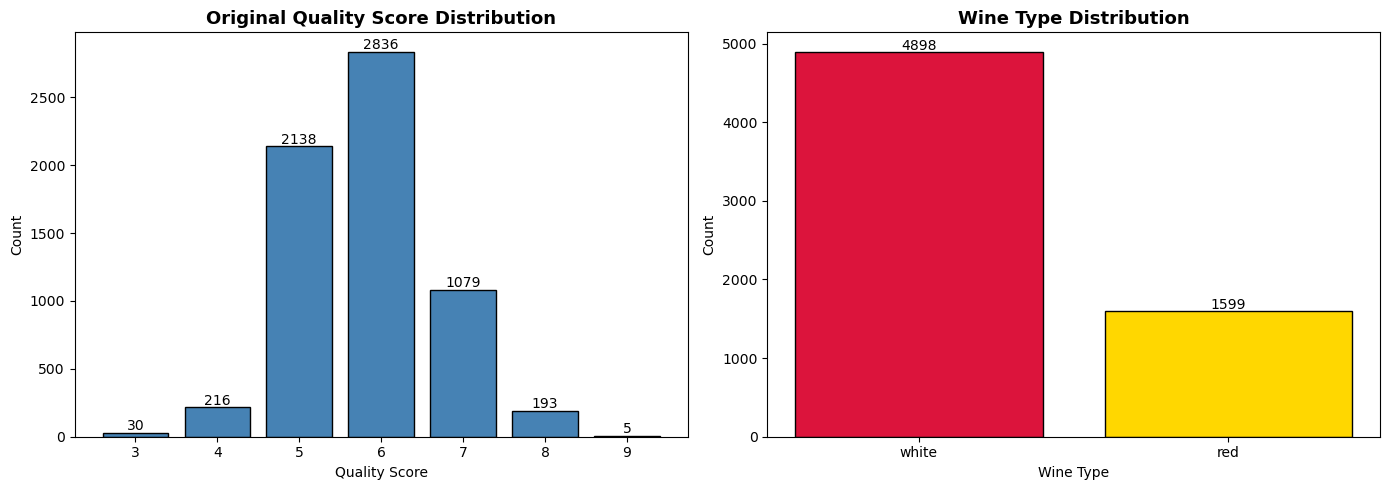


Quality score counts:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Key observation: Scores 5 and 6 dominate → imbalanced classification problem


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality score distribution
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Original Quality Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
for i, (score, count) in enumerate(quality_counts.items()):
    axes[0].text(score, count + 20, str(count), ha='center', fontsize=10)

# Wine type distribution
type_counts = df['type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=['crimson', 'gold'], edgecolor='black')
axes[1].set_title('Wine Type Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Wine Type')
axes[1].set_ylabel('Count')
for i, (wtype, count) in enumerate(type_counts.items()):
    axes[1].text(i, count + 20, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nQuality score counts:\n{quality_counts}")
print(f"\nKey observation: Scores 5 and 6 dominate → imbalanced classification problem")

### 3.3 Feature Distributions

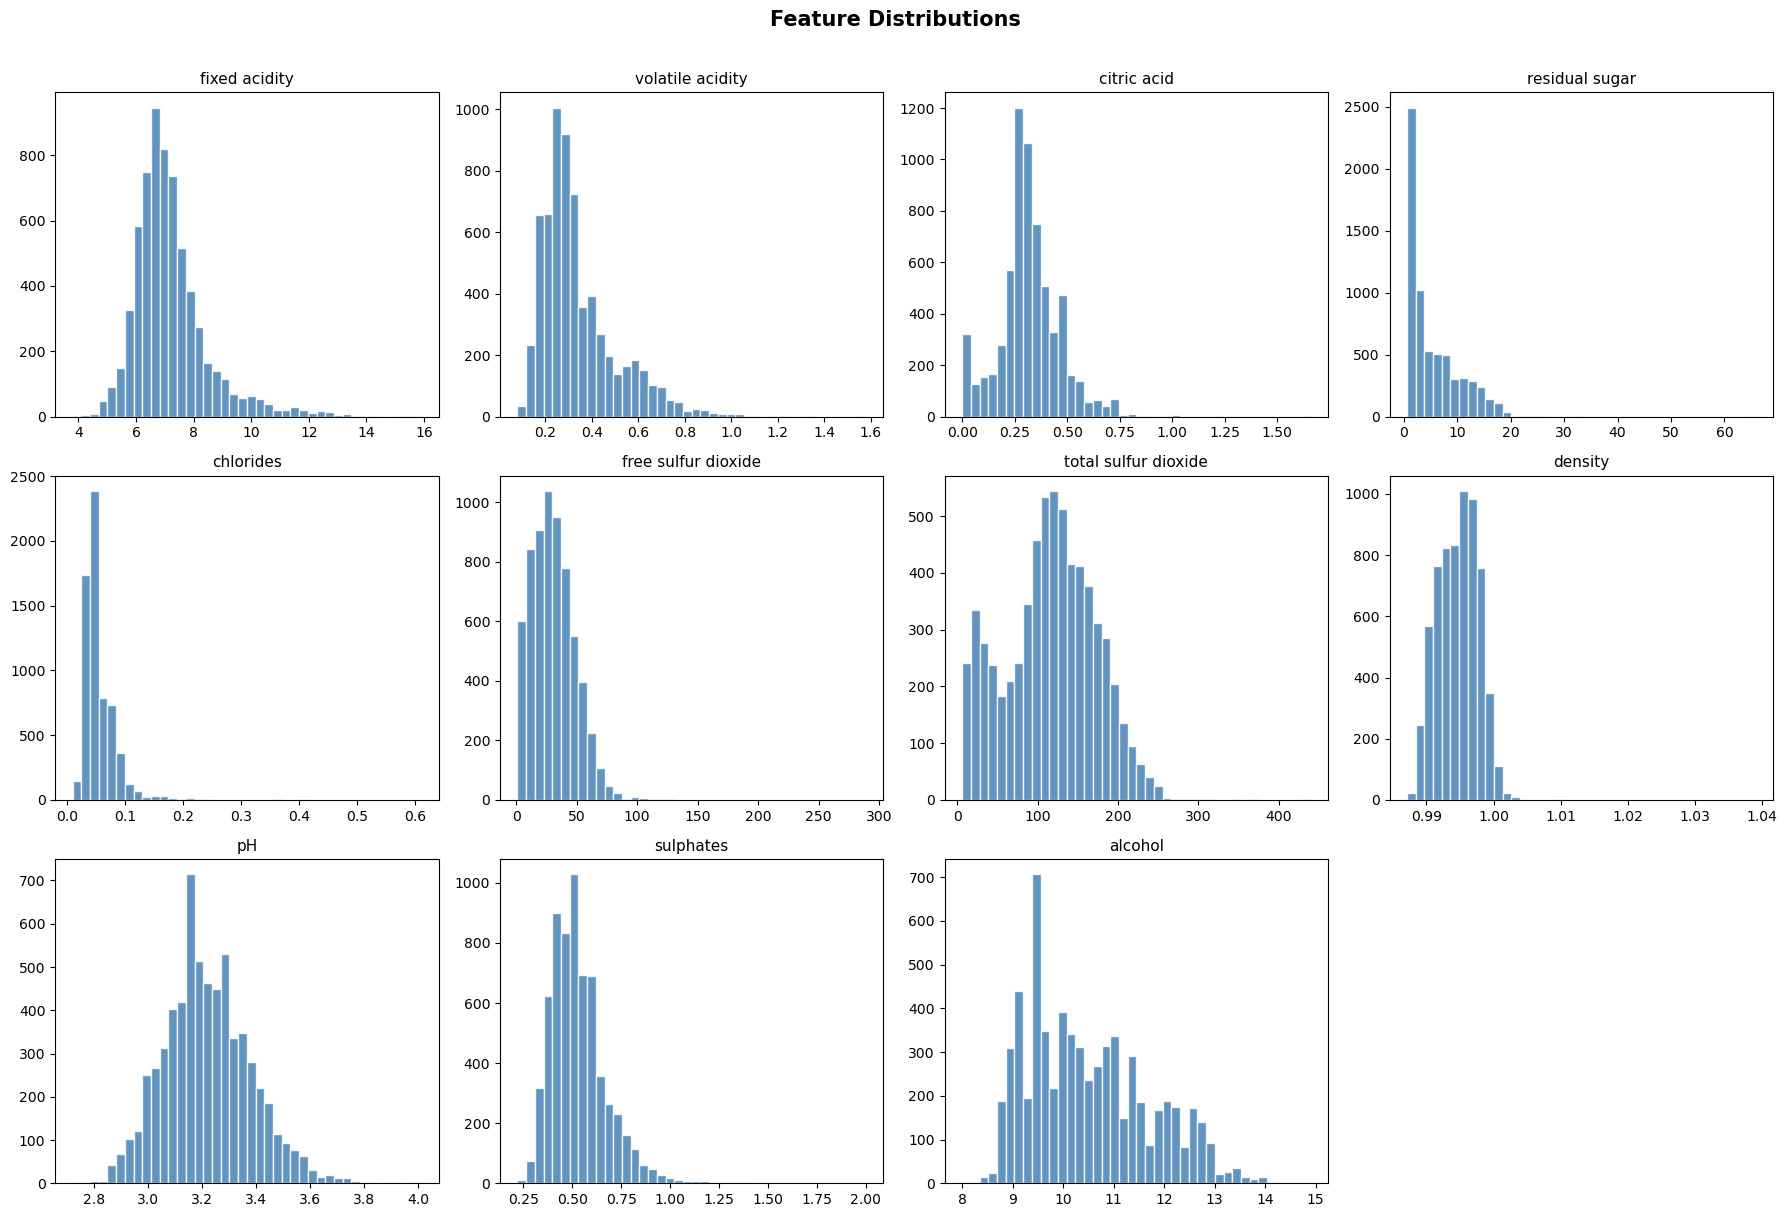

In [5]:
numeric_features = df.select_dtypes(include='number').columns.tolist()
numeric_features.remove('quality')

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

# Hide the last empty subplot
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

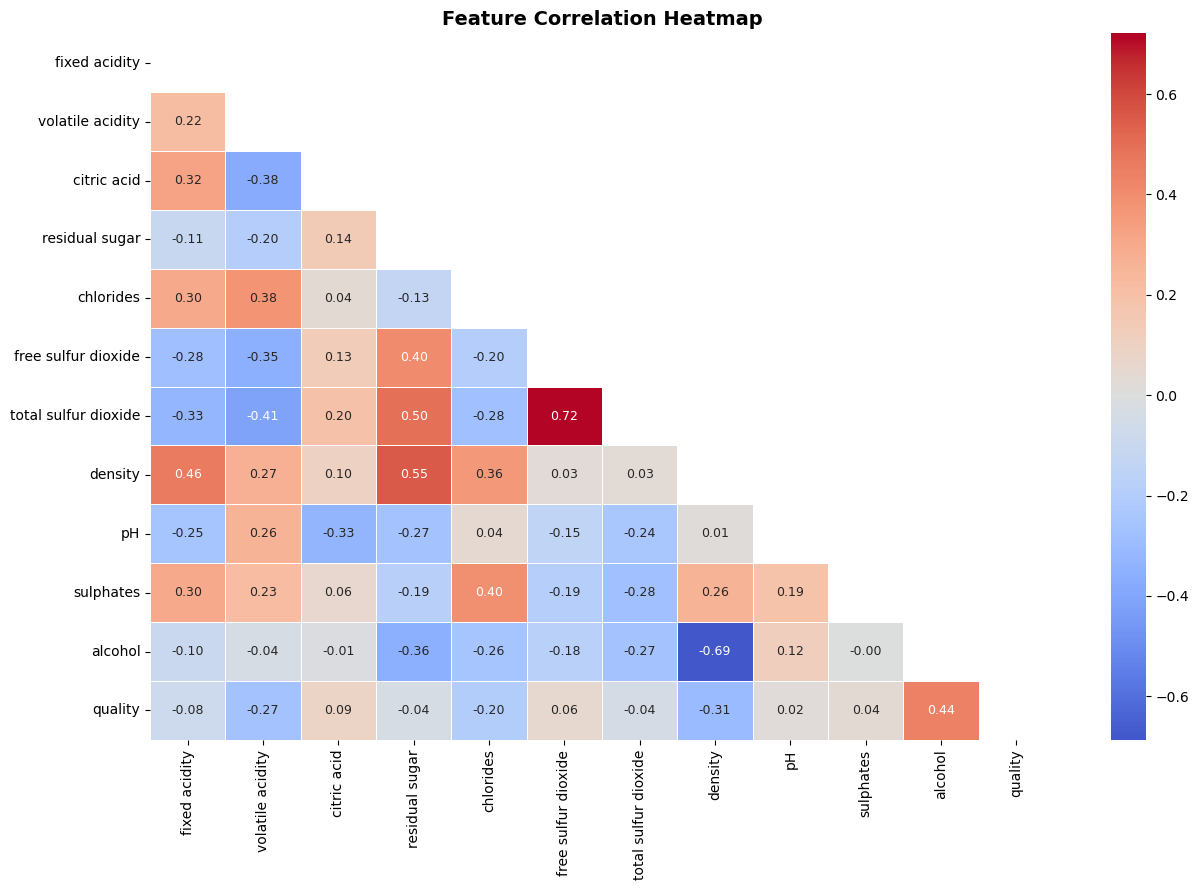

Top features correlated with quality:
alcohol                 0.444
density                 0.306
volatile acidity        0.266
chlorides               0.201
citric acid             0.086
fixed acidity           0.077
free sulfur dioxide     0.055
total sulfur dioxide    0.041
sulphates               0.038
residual sugar          0.037
pH                      0.020
Name: quality, dtype: float64


In [6]:
plt.figure(figsize=(13, 9))
corr = df[numeric_features + ['quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with quality
print('Top features correlated with quality:')
print(corr['quality'].drop('quality').abs().sort_values(ascending=False).round(3))

### 3.5 Feature vs Quality Boxplots (Key Features)

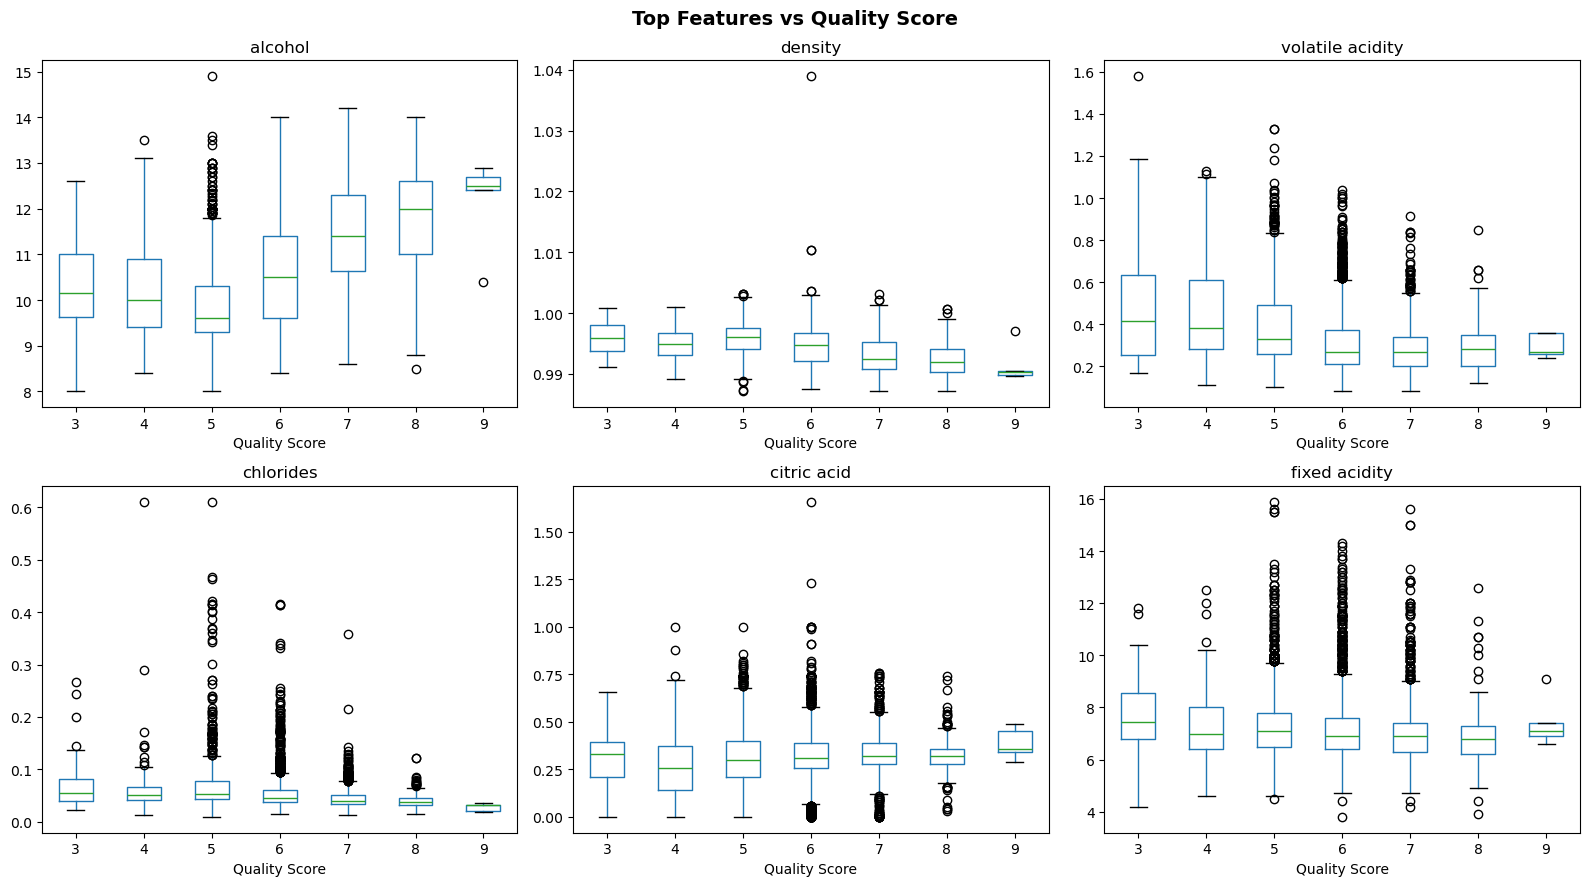

In [7]:
top_features = corr['quality'].drop('quality').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='quality', ax=axes[i], grid=False)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Quality Score')
    plt.sca(axes[i])
    plt.title(feat)

plt.suptitle('Top Features vs Quality Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Target Transformation
### 4.1 Binary Target: Good Wine vs Bad Wine

=== Binary Target Distribution ===
target
0    5220
1    1277
Name: count, dtype: int64

Class balance: 5220 bad (80.3%) | 1277 good (19.7%)


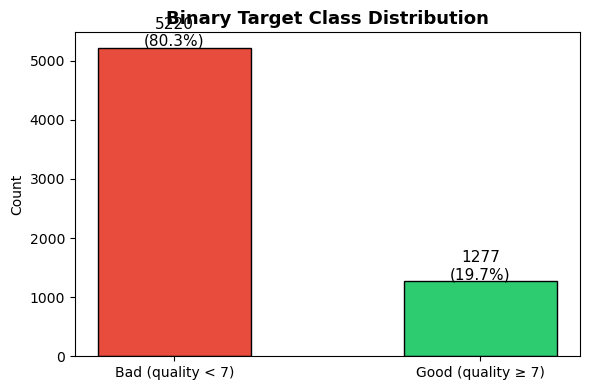

In [8]:
# Transform quality into binary target
# Good wine: quality >= 7  →  1
# Bad wine:  quality < 7   →  0
df['target'] = (df['quality'] >= 7).astype(int)

print('=== Binary Target Distribution ===')
target_counts = df['target'].value_counts()
print(target_counts)
print(f'\nClass balance: {target_counts[0]} bad ({target_counts[0]/len(df)*100:.1f}%) | {target_counts[1]} good ({target_counts[1]/len(df)*100:.1f}%)')

# Visualize new target balance
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Bad (quality < 7)', 'Good (quality ≥ 7)'], target_counts.values,
       color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for i, count in enumerate(target_counts.values):
    ax.text(i, count + 30, f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Binary Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Encode Categorical Feature (wine type)

In [9]:
# Encode 'type': red=1, white=0
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Define features and target
feature_cols = numeric_features + ['type_encoded']
X = df[feature_cols]
y = df['target']

print(f'\nFeatures shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Feature columns: {feature_cols}')

Label encoding: {'red': 0, 'white': 1}

Features shape: (6497, 12)
Target shape:   (6497,)
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_encoded']


### 4.3 Train/Test Split

In [10]:
# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'\nTrain class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')

Training set:   5197 samples
Test set:       1300 samples

Train class balance: {0: 4176, 1: 1021}
Test class balance:  {0: 1044, 1: 256}


### 4.4 Feature Scaling

In [11]:
# Gradient boosting trees don't require scaling,
# but it is good practice for fair comparison and reproducibility
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print('Scaling complete ')
print('Note: Tree-based models will use unscaled data (XGBoost, LightGBM, CatBoost are scale-invariant)')

Scaling complete 
Note: Tree-based models will use unscaled data (XGBoost, LightGBM, CatBoost are scale-invariant)


## 5. Compute Class Weight (for imbalance handling)

In [12]:
# Calculate scale_pos_weight for XGBoost (ratio of negatives to positives)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Negative samples (bad wine):  {neg}')
print(f'Positive samples (good wine): {pos}')
print(f'scale_pos_weight (neg/pos):   {scale_pos_weight:.2f}')
print('\nThis value will be passed to XGBoost to handle class imbalance.')

Negative samples (bad wine):  4176
Positive samples (good wine): 1021
scale_pos_weight (neg/pos):   4.09

This value will be passed to XGBoost to handle class imbalance.


## 6. Model Training & Hyperparameter Tuning

We use `GridSearchCV` with 5-fold stratified cross-validation and **F1 score** as the scoring metric.
### 6.1 XGBoost

In [13]:
xgb_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.05, 0.1],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_grid = GridSearchCV(
    xgb_base, xgb_param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)

print('Training XGBoost with GridSearchCV...')
xgb_grid.fit(X_train, y_train)

print(f'\nBest XGBoost params: {xgb_grid.best_params_}')
print(f'Best CV F1 Score:    {xgb_grid.best_score_:.4f}')

xgb_best = xgb_grid.best_estimator_

Training XGBoost with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 Score:    0.6721


### 6.2 LightGBM

In [14]:
lgbm_param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [3, 5, 7],
    'learning_rate':  [0.05, 0.1],
    'num_leaves':     [31, 63],
    'subsample':      [0.8, 1.0]
}

# is_unbalance=True automatically adjusts for class imbalance in LightGBM
lgbm_base = LGBMClassifier(
    is_unbalance=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm_grid = GridSearchCV(
    lgbm_base, lgbm_param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)

print('Training LightGBM with GridSearchCV...')
lgbm_grid.fit(X_train, y_train)

print(f'\nBest LightGBM params: {lgbm_grid.best_params_}')
print(f'Best CV F1 Score:     {lgbm_grid.best_score_:.4f}')

lgbm_best = lgbm_grid.best_estimator_

Training LightGBM with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best LightGBM params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 63, 'subsample': 0.8}
Best CV F1 Score:     0.6540


### 6.3 CatBoost

In [15]:
cat_param_grid = {
    'iterations':   [100, 200],
    'depth':        [4, 6, 8],
    'learning_rate':[0.05, 0.1],
    'l2_leaf_reg':  [1, 3]
}

# auto_class_weights='Balanced' handles imbalance in CatBoost
cat_base = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_seed=SEED,
    verbose=0
)

cat_grid = GridSearchCV(
    cat_base, cat_param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)

print('Training CatBoost with GridSearchCV...')
cat_grid.fit(X_train, y_train)

print(f'\nBest CatBoost params: {cat_grid.best_params_}')
print(f'Best CV F1 Score:     {cat_grid.best_score_:.4f}')

cat_best = cat_grid.best_estimator_

Training CatBoost with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best CatBoost params: {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best CV F1 Score:     0.6596


## 7. Model Evaluation on Test Set

In [16]:
models = {
    'XGBoost':  xgb_best,
    'LightGBM': lgbm_best,
    'CatBoost': cat_best
}

results = {}

print('=' * 60)
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'F1 Score': round(f1, 4),
        'ROC-AUC':  round(auc, 4),
        'y_pred':   y_pred
    }

    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['Bad Wine', 'Good Wine']))

print('=' * 60)


--- XGBoost ---
              precision    recall  f1-score   support

    Bad Wine       0.93      0.88      0.91      1044
   Good Wine       0.60      0.73      0.66       256

    accuracy                           0.85      1300
   macro avg       0.77      0.80      0.78      1300
weighted avg       0.87      0.85      0.86      1300


--- LightGBM ---
              precision    recall  f1-score   support

    Bad Wine       0.93      0.90      0.91      1044
   Good Wine       0.63      0.71      0.67       256

    accuracy                           0.86      1300
   macro avg       0.78      0.80      0.79      1300
weighted avg       0.87      0.86      0.86      1300


--- CatBoost ---
              precision    recall  f1-score   support

    Bad Wine       0.93      0.88      0.90      1044
   Good Wine       0.59      0.73      0.66       256

    accuracy                           0.85      1300
   macro avg       0.76      0.81      0.78      1300
weighted avg       0.

### 7.1 Confusion Matrices

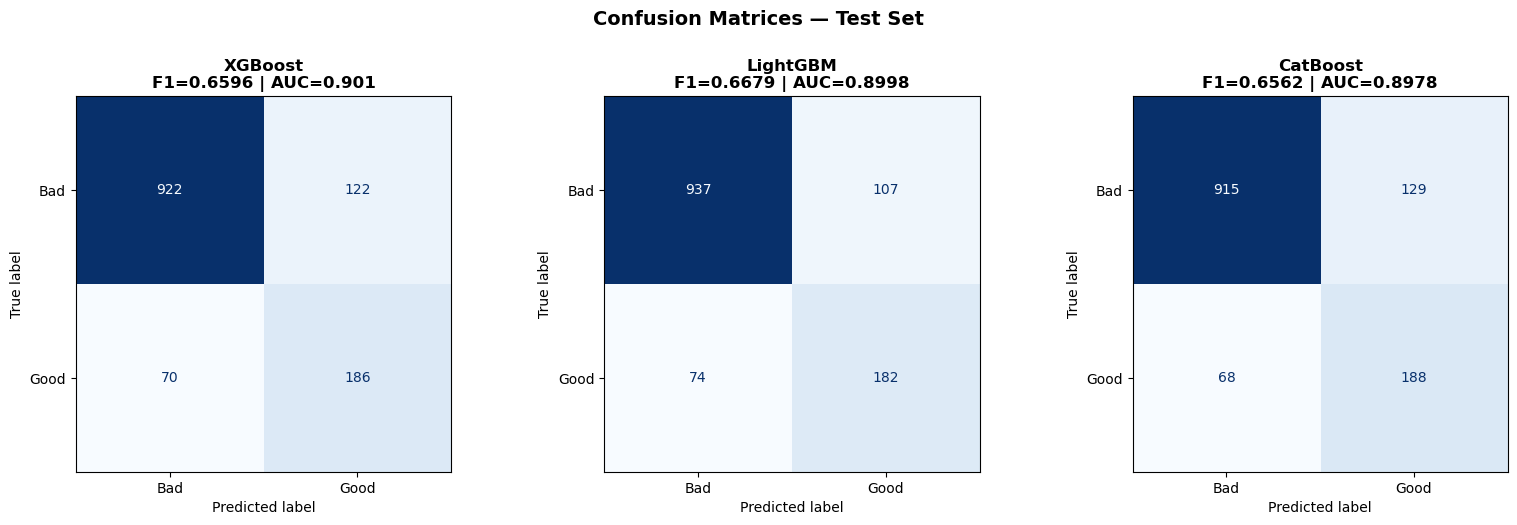

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad', 'Good'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={res["F1 Score"]} | AUC={res["ROC-AUC"]}',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 F1 Score & ROC-AUC Comparison

=== Final Model Comparison ===
   Model  F1 Score  ROC-AUC
LightGBM    0.6679   0.8998
 XGBoost    0.6596   0.9010
CatBoost    0.6562   0.8978


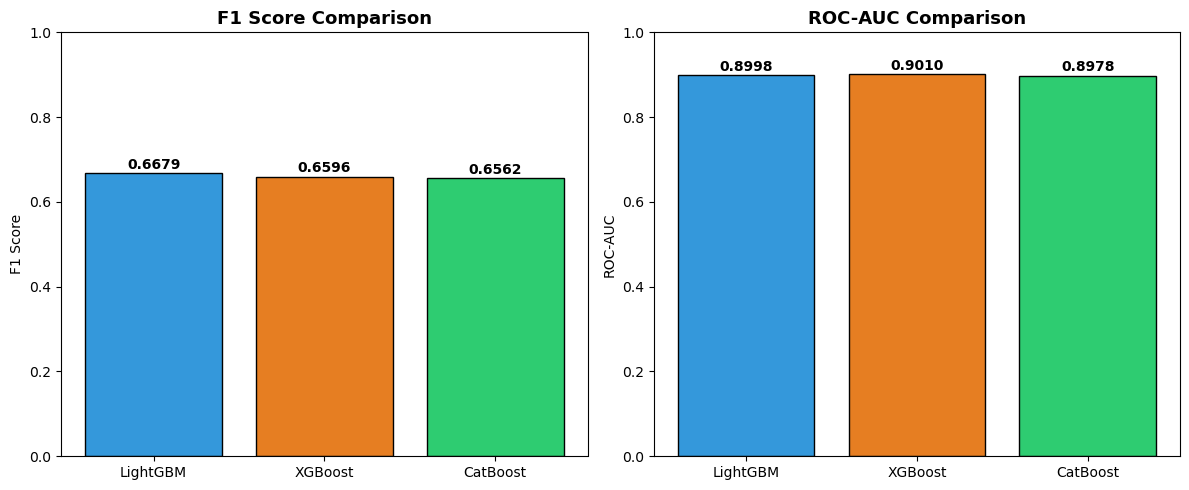

In [18]:
# Summary DataFrame
summary_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'F1 Score': [v['F1 Score'] for v in results.values()],
    'ROC-AUC':  [v['ROC-AUC']  for v in results.values()]
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('=== Final Model Comparison ===')
print(summary_df.to_string(index=False))

# Bar plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#3498db', '#e67e22', '#2ecc71']

# F1 Score
axes[0].bar(summary_df['Model'], summary_df['F1 Score'], color=colors, edgecolor='black')
axes[0].set_ylim(0, 1)
axes[0].set_title('F1 Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1 Score')
for i, val in enumerate(summary_df['F1 Score']):
    axes[0].text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

# ROC-AUC
axes[1].bar(summary_df['Model'], summary_df['ROC-AUC'], color=colors, edgecolor='black')
axes[1].set_ylim(0, 1)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC')
for i, val in enumerate(summary_df['ROC-AUC']):
    axes[1].text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Feature Importance

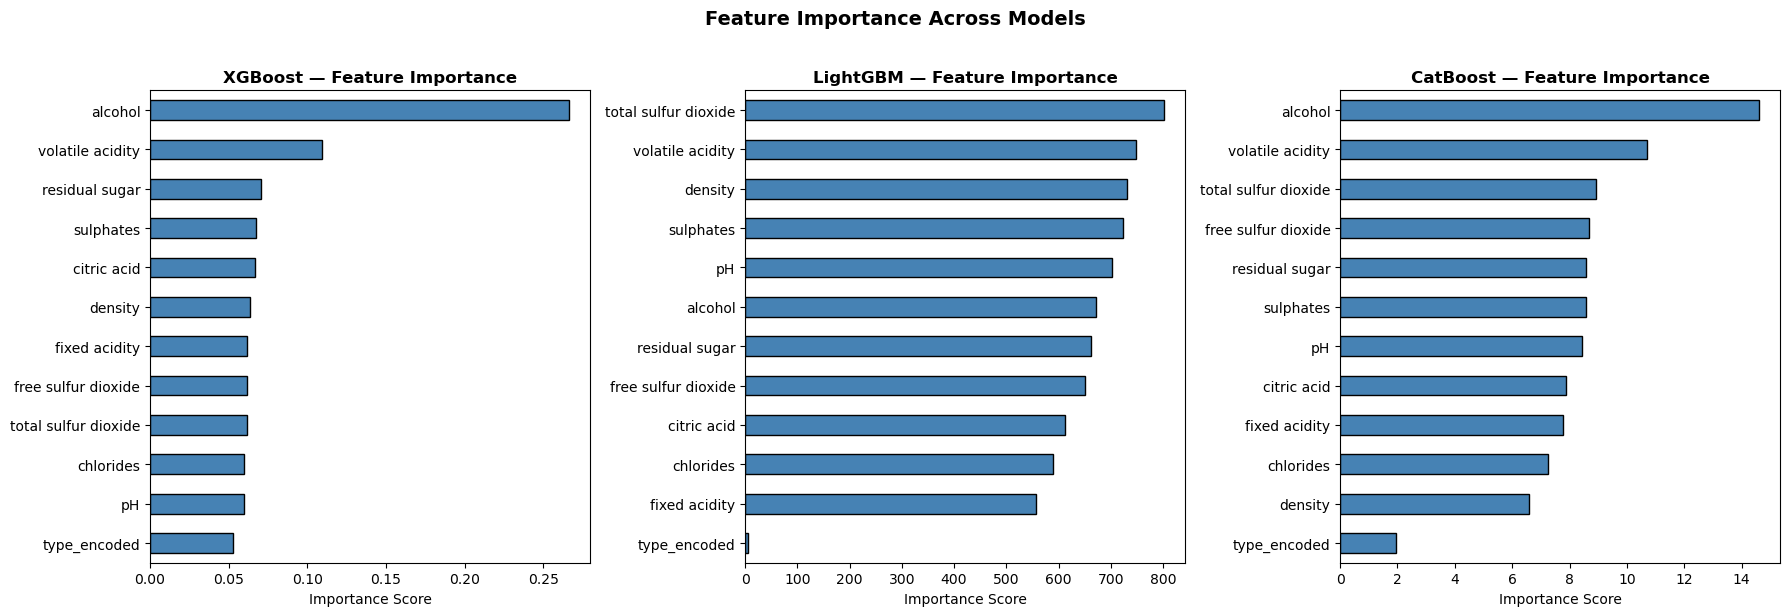

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, models.items()):
    if name == 'CatBoost':
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_

    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{name} — Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Across Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary & Conclusion

In [20]:
best_model_name = summary_df.iloc[0]['Model']
best_f1         = summary_df.iloc[0]['F1 Score']
best_auc        = summary_df.iloc[0]['ROC-AUC']

print('=' * 55)
print('       WINE QUALITY CLASSIFICATION — SUMMARY')
print('=' * 55)
print(f'  Dataset:       6,497 wines (red + white merged)')
print(f'  Task:          Binary classification (good vs bad)')
print(f'  Target:        quality >= 7 → Good (1), else Bad (0)')
print(f'  Class ratio:   ~{neg}:{pos} (imbalanced → handled via weights)')
print(f'  Primary metric: F1 Score')
print()
print('  Model Results:')
for _, row in summary_df.iterrows():
    marker = '  ★ BEST' if row['Model'] == best_model_name else ''
    print(f"    {row['Model']:10s} | F1: {row['F1 Score']:.4f} | AUC: {row['ROC-AUC']:.4f}{marker}")
print()
print(f'  🏆 Best Model:  {best_model_name}')
print(f'     F1 Score = {best_f1} | ROC-AUC = {best_auc}')
print('=' * 55)

print("""
Key Takeaways:
  • Alcohol content and volatile acidity are consistently
    the most important features across all three models.
  • All three gradient boosting models handled the class
    imbalance well using their built-in weighting mechanisms.
  • GridSearchCV + StratifiedKFold ensured reliable tuning
    on imbalanced data.
""")

       WINE QUALITY CLASSIFICATION — SUMMARY
  Dataset:       6,497 wines (red + white merged)
  Task:          Binary classification (good vs bad)
  Target:        quality >= 7 → Good (1), else Bad (0)
  Class ratio:   ~4176:1021 (imbalanced → handled via weights)
  Primary metric: F1 Score

  Model Results:
    LightGBM   | F1: 0.6679 | AUC: 0.8998  ★ BEST
    XGBoost    | F1: 0.6596 | AUC: 0.9010
    CatBoost   | F1: 0.6562 | AUC: 0.8978

  🏆 Best Model:  LightGBM
     F1 Score = 0.6679 | ROC-AUC = 0.8998

Key Takeaways:
  • Alcohol content and volatile acidity are consistently
    the most important features across all three models.
  • All three gradient boosting models handled the class
    imbalance well using their built-in weighting mechanisms.
  • GridSearchCV + StratifiedKFold ensured reliable tuning
    on imbalanced data.

